In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
x,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=1,random_state=13)

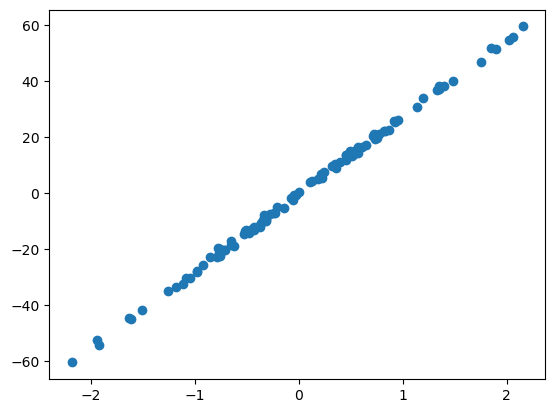

In [3]:
plt.scatter(x,y)

In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
print(x_train.shape)
print(y_train.shape)

(80, 1)
(80,)


In [7]:
lr = LinearRegression()

In [8]:
lr.fit(x_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[27.63419174]
-0.11355072130891863


In [9]:
y_pred =  lr.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9987444871369818

In [16]:
class GDRegressor:
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
    def fit(self,x,y):
        for i in range(self.epochs):
            loss_slope_b = -2*np.sum(y- self.m*x.ravel() - self.b)
            loss_slope_m = -2*np.sum((y-self.m*x.ravel() - self.b)*x.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)

    def predict(self,x):
        return self.m * x + self.b

In [17]:
gd = GDRegressor(0.001,50)


In [18]:
gd.fit(x_train,y_train)

27.667956143590878 -0.14344665817553862


In [19]:
y_pred = gd.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9987322969839406